In [11]:
# %%
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# Config
# ----------------------------
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = PROJECT_ROOT / "data" / "visitor_features_engineered.parquet"
MIN_STARTERS = 100  # adjust if you want broader/narrower coverage

# Optional: force consistent x-axis across domains for easier comparison
FIX_X_AXIS = True
X_MAX = 0.40  # set based on what you expect; adjust after a first run if needed

In [2]:
# %%
# ----------------------------
# Load + define abandonment
# ----------------------------
df = pd.read_parquet(DATA_PATH)

df.shape

(535391, 15)

In [3]:
# %%
df_started = df[df["test_engagement_state"] != "No Test"].copy()

df_started["abandoned"] = (
    df_started["test_engagement_state"] == "Test Started Only"
)

df_started["abandoned"].value_counts(normalize=True)

abandoned
False    0.845744
True     0.154256
Name: proportion, dtype: float64

In [5]:
# %%
# ----------------------------
# Compute domain ordering by aggregate abandonment
# (among test starters within each domain)
# ----------------------------
domain_order = (
    df_started.groupby("first_test_domain")["abandoned"]
    .mean()
    .sort_values(ascending=False)
    .index
    .tolist()
)

domain_order

['Life, Work & Physical Health',
 'Anxiety & Stress',
 'Sexual & Gender Health',
 'Trauma & Dissociation',
 'Addiction & Compulsive Behavior',
 'Neurodevelopmental & Cognitive',
 'Mood & Depression',
 'Personality Disorders & Traits']

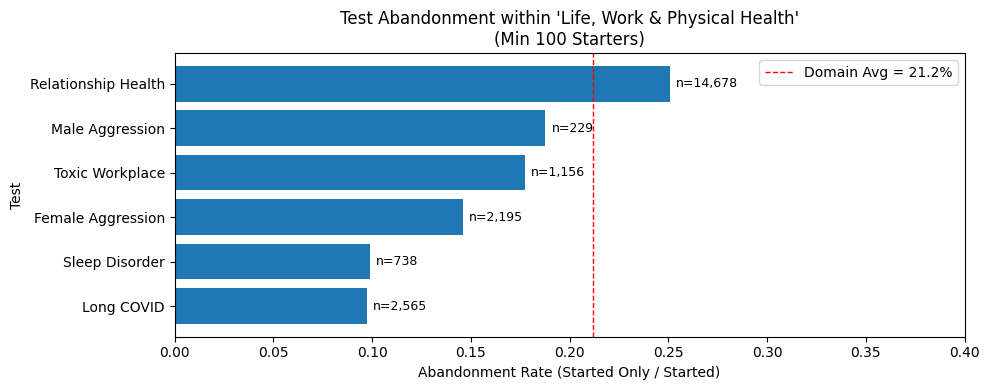

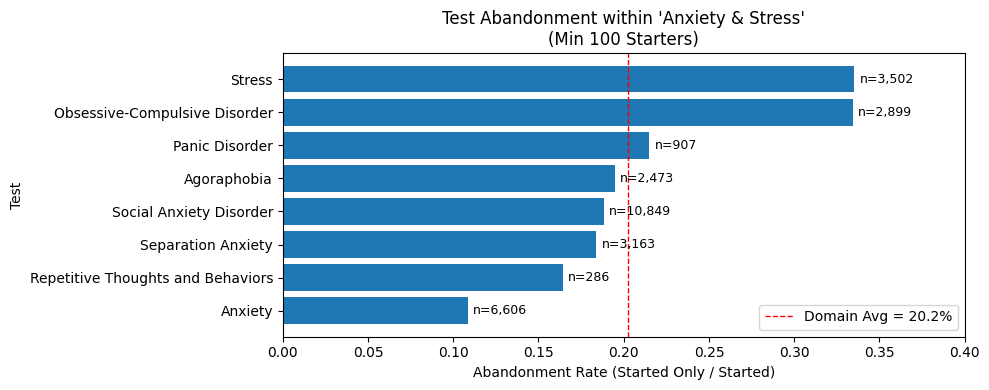

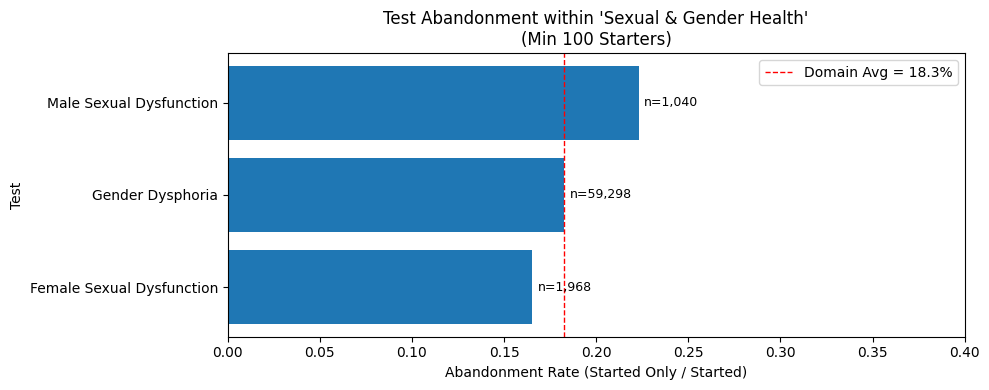

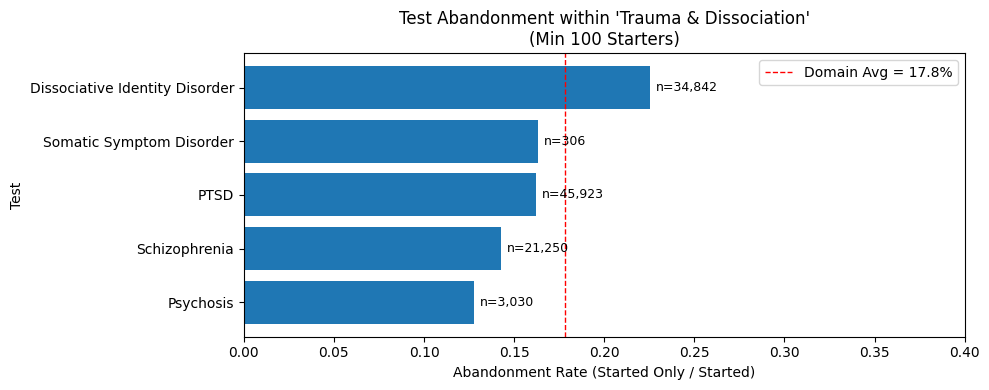

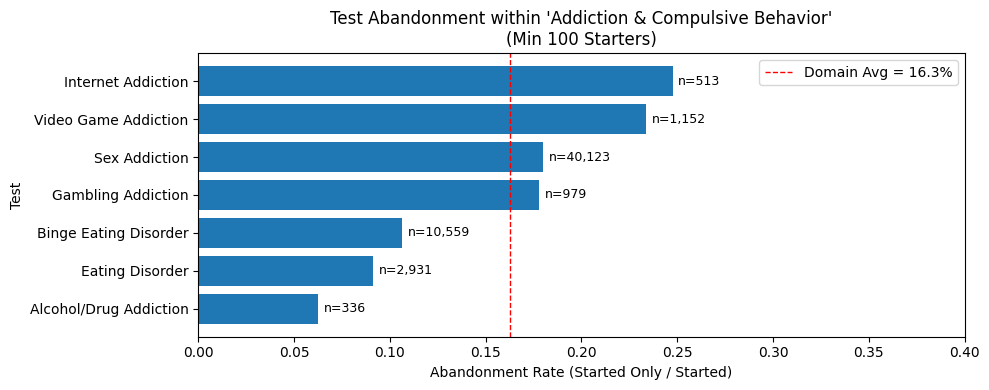

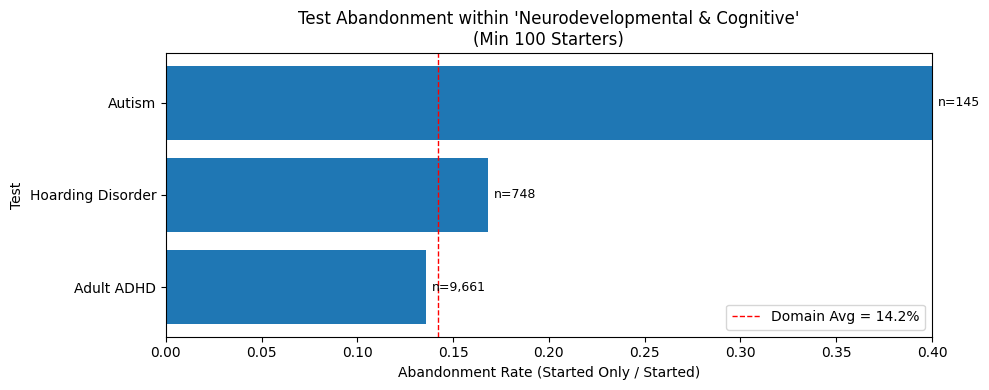

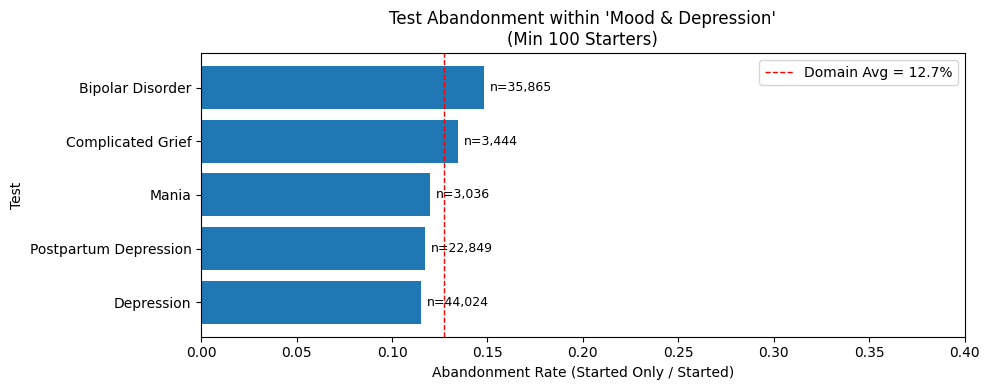

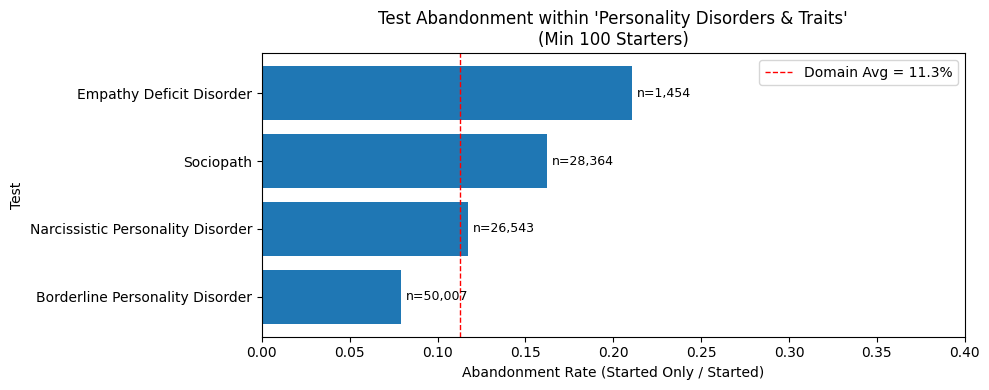

In [12]:
# %%
# ----------------------------
# Loop domains and plot ranked bars
# ----------------------------
for domain in domain_order:
    df_domain = df_started[df_started["first_test_domain"] == domain].copy()

    # Domain-level average abandonment (reference line)
    domain_avg_abandonment = df_domain["abandoned"].mean()

    # Aggregate abandonment by individual test (first test taken)
    test_abandonment = (
        df_domain.groupby("first_test_taken")
        .agg(
            started_visitors=("visitor_key", "count"),
            abandoned_visitors=("abandoned", "sum"),
        )
        .assign(
            abandonment_rate=lambda d: d["abandoned_visitors"] / d["started_visitors"]
        )
        .sort_values("abandonment_rate", ascending=False)
    )

    # Apply minimum volume threshold
    test_abandonment_filt = test_abandonment[
        test_abandonment["started_visitors"] >= MIN_STARTERS
    ].copy()

    # Skip domains with no tests meeting threshold
    if test_abandonment_filt.empty:
        print(f"Skipping '{domain}' (no tests with ≥ {MIN_STARTERS} starters)")
        continue

    # Plot
    plt.figure(figsize=(10, max(4, 0.35 * len(test_abandonment_filt) + 1)))

    plt.barh(
        test_abandonment_filt.index,
        test_abandonment_filt["abandonment_rate"],
    )

    # Domain average reference line
    plt.axvline(
        domain_avg_abandonment,
        linestyle="--",
        linewidth=1,
        color="red",
        label=f"Domain Avg = {domain_avg_abandonment:.1%}",
    )

    # Annotate volume (n starters) at end of each bar
    for i, (rate, volume) in enumerate(
        zip(
            test_abandonment_filt["abandonment_rate"],
            test_abandonment_filt["started_visitors"],
        )
    ):
        plt.text(
            rate + 0.003,
            i,
            f"n={volume:,}",
            va="center",
            fontsize=9,
        )

    plt.xlabel("Abandonment Rate (Started Only / Started)")
    plt.ylabel("Test")
    plt.title(
        f"Test Abandonment within '{domain}'\n"
        f"(Min {MIN_STARTERS} Starters)"
    )

    if FIX_X_AXIS:
        plt.xlim(0, X_MAX)

    plt.legend()
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()